In [10]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Sample market basket data
transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Diaper', 'Beer', 'Bread'],
    ['Milk', 'Beer', 'Diaper']
]

# 1. Data ko One-Hot Encode karna
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_basket = pd.DataFrame(te_ary, columns=te.columns_)

# 2. Apriori algorithm run karna (Frequent items)
frequent_itemsets = apriori(df_basket, min_support=0.4, use_colnames=True)

# 3. Association Rules generate karna
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,frozenset({Diaper}),frozenset({Beer}),0.4,1.0,2.50
1,frozenset({Beer}),frozenset({Diaper}),0.4,1.0,2.50
2,frozenset({Milk}),frozenset({Beer}),0.4,0.5,1.25
3,frozenset({Beer}),frozenset({Milk}),0.4,1.0,1.25
4,frozenset({Bread}),frozenset({Butter}),0.4,0.5,1.25
5,frozenset({Butter}),frozenset({Bread}),0.4,1.0,1.25
6,frozenset({Diaper}),frozenset({Milk}),0.4,1.0,1.25
7,frozenset({Milk}),frozenset({Diaper}),0.4,0.5,1.25
8,"frozenset({Diaper, Milk})",frozenset({Beer}),0.4,1.0,2.50
9,"frozenset({Diaper, Beer})",frozenset({Milk}),0.4,1.0,1.25


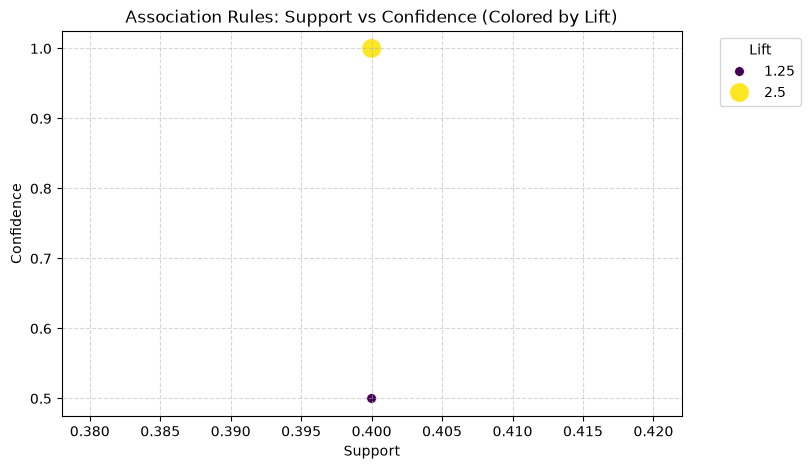

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot ka size
plt.figure(figsize=(8, 5))

# Scatter plot: x-axis = support, y-axis = confidence, hue/color = lift
scatter = sns.scatterplot(
    x="support", 
    y="confidence", 
    hue="lift", 
    palette="viridis", 
    size="lift", 
    sizes=(50, 200),
    data=rules
)

plt.title("Association Rules: Support vs Confidence (Colored by Lift)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Lift")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_17424\1503794325.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lift', y='rule', data=top_rules, palette='magma')


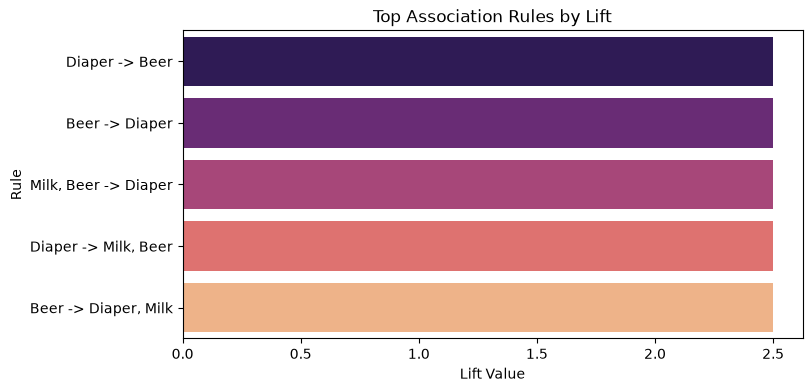

In [12]:
# Rules ko readable string banana (e.g. Diaper -> Beer)
rules['rule'] = rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' + \
                rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Top 5 rules lift ke hisaab se
top_rules = rules.sort_values('lift', ascending=False).head(5)

plt.figure(figsize=(8, 4))
sns.barplot(x='lift', y='rule', data=top_rules, palette='magma')
plt.title("Top Association Rules by Lift")
plt.xlabel("Lift Value")
plt.ylabel("Rule")
plt.show()

In [13]:
df = pd.read_csv(r"C:\Users\dell\Downloads\Groceries_dataset.csv")
df.head(5)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [14]:
# 1. Ek customer aur ek date ke items ko ek list (basket) mein group karein
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

# Pehle 3 baskets check karein
print(transactions[:3])

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages']]


In [17]:
# 2. One-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_basket = pd.DataFrame(te_ary, columns=te.columns_)

# 3. Frequent itemsets (real dataset badi hoti hai, isliye min_support 0.001 ya 0.005 rakhein)
frequent_itemsets = apriori(df_basket, min_support=0.001, use_colnames=True)

# 4. Association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
236,"frozenset({whole milk, yogurt})",frozenset({sausage}),0.001470,0.131737,2.182917
237,frozenset({sausage}),"frozenset({whole milk, yogurt})",0.001470,0.024363,2.182917
234,"frozenset({sausage, whole milk})",frozenset({yogurt}),0.001470,0.164179,1.911760
239,frozenset({yogurt}),"frozenset({sausage, whole milk})",0.001470,0.017121,1.911760
86,frozenset({citrus fruit}),frozenset({specialty chocolate}),0.001403,0.026415,1.653762
87,frozenset({specialty chocolate}),frozenset({citrus fruit}),0.001403,0.087866,1.653762
235,"frozenset({sausage, yogurt})",frozenset({whole milk}),0.001470,0.255814,1.619866
238,frozenset({whole milk}),"frozenset({sausage, yogurt})",0.001470,0.009310,1.619866
122,frozenset({tropical fruit}),frozenset({flour}),0.001069,0.015779,1.617141
123,frozenset({flour}),frozenset({tropical fruit}),0.001069,0.109589,1.617141


In [19]:
df.shape

(38765, 3)

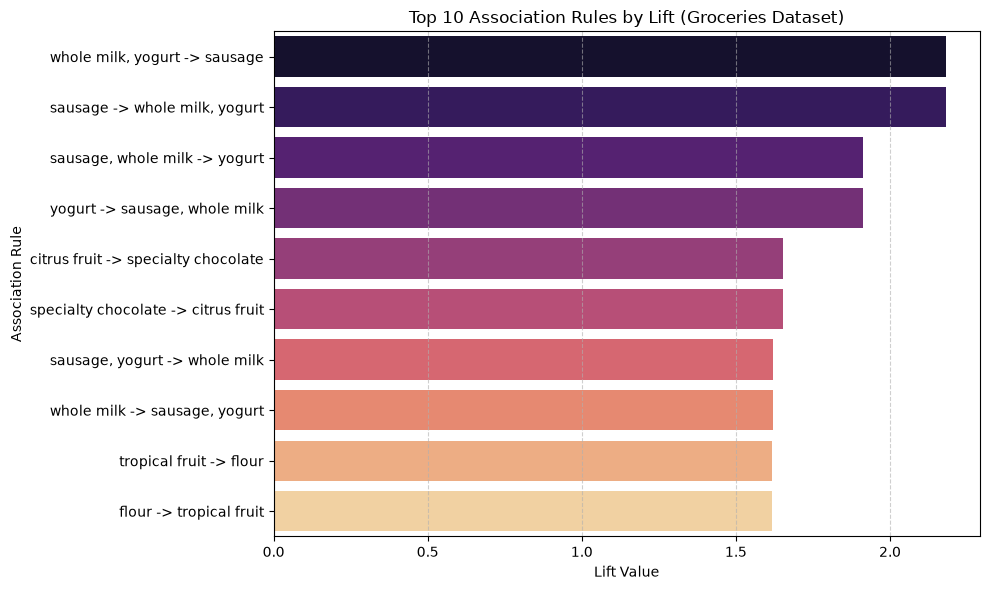

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rule ka readable naam banana (e.g. {whole milk, yogurt} -> {sausage})
top_rules = rules.sort_values('lift', ascending=False).head(10).copy()
top_rules['rule'] = (
    top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    + ' -> '
    + top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_rules,
    x='lift',
    y='rule',
    hue='rule',
    palette='magma',
    legend=False
)
plt.title('Top 10 Association Rules by Lift (Groceries Dataset)')
plt.xlabel('Lift Value')
plt.ylabel('Association Rule')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

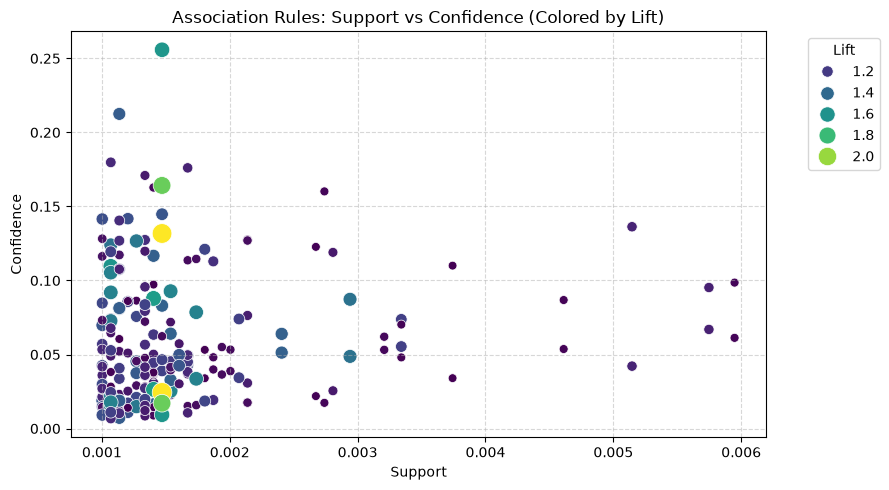

In [21]:
plt.figure(figsize=(9, 5))
scatter = sns.scatterplot(
    data=rules,
    x='support',
    y='confidence',
    hue='lift',
    size='lift',
    palette='viridis',
    sizes=(40, 200)
)

plt.title('Association Rules: Support vs Confidence (Colored by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lift')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
transactions

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['sausage', 'rolls/buns'],
 ['root vegetables', 'detergent'],
 ['frozen meals', 'dental care'],
 ['rolls/buns', 'rolls/buns'],
 ['dish cleaner', 'cling film/bags'],
 ['canned beer', 'frozen fish'],
 ['other vegetables', 'hygiene articles'],
 ['pip fruit', 'whole milk', 'tropical fruit'],
 ['rolls/buns', 'red/blush wine', 'chocolate'],
 ['other vegetables', 'shopping bags'],
 ['whole milk', 'chocolate', 'packaged fruit/vegetables', 'rolls/buns'],
 ['root vegetables', 'whole milk'

In [24]:
# Grouped data ko DataFrame format mein dekhna
basket_df = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()

# Column ka naam readable rakhne ke liye rename karein
basket_df.rename(columns={'itemDescription': 'Basket_Items'}, inplace=True)

# Pehle 5 rows dekhein
basket_df.head()

,Member_number,Date,Basket_Items
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yog..."
1,1000,24-06-2014,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,"[canned beer, misc. beverages]"
3,1000,25-11-2015,"[sausage, hygiene articles]"
4,1000,27-05-2015,"[soda, pickled vegetables]"


In [25]:
basket_df['Item_Count'] = basket_df['Basket_Items'].apply(len)
basket_df.head()

,Member_number,Date,Basket_Items,Item_Count
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yog...",4
1,1000,24-06-2014,"[whole milk, pastry, salty snack]",3
2,1000,24-07-2015,"[canned beer, misc. beverages]",2
3,1000,25-11-2015,"[sausage, hygiene articles]",2
4,1000,27-05-2015,"[soda, pickled vegetables]",2


In [26]:
basket_df['Item_Count'].mean()

np.float64(2.590723785337165)

In [27]:
basket_df['Item_Count'].describe()

count    14963.000000
mean         2.590724
std          1.117469
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: Item_Count, dtype: float64

In [32]:
member_1000_baskets = basket_df[basket_df['Member_number'] == 2552]
member_1000_baskets

,Member_number,Date,Basket_Items,Item_Count
5779,2552,05-01-2015,"[whole milk, tropical fruit, chocolate]",3
5780,2552,08-10-2014,"[butter, root vegetables]",2
5781,2552,11-07-2014,"[pot plants, shopping bags, coffee]",3
5782,2552,19-02-2014,"[other vegetables, chocolate]",2
5783,2552,20-06-2014,"[female sanitary products, whole milk, hygiene...",3


In [30]:
df.Member_number.unique()

array([1808, 2552, 2300, ..., 3607, 4587, 2417], shape=(3898,))

In [33]:
df.itemDescription.unique()

<ArrowStringArray>
[       'tropical fruit',            'whole milk',             'pip fruit',
      'other vegetables',            'rolls/buns',            'pot plants',
          'citrus fruit',                  'beef',           'frankfurter',
               'chicken',
 ...
        'flower (seeds)',                  'rice',                   'tea',
        'salad dressing',  'specialty vegetables',        'pudding powder',
           'ready soups',       'make up remover',        'toilet cleaner',
 'preservation products']
Length: 167, dtype: str

In [36]:
df_basket

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
14959,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14960,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14961,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
